In [7]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 3
BASE = 'round3'
DAYS = ['0', '1', '2']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

hp_prices  = prices[prices['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
vfe_prices = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

print(f'HYDROGEL_PACK rows      : {len(hp_prices)}')
print(f'VELVETFRUIT_EXTRACT rows: {len(vfe_prices)}')

HYDROGEL_PACK rows      : 30000
VELVETFRUIT_EXTRACT rows: 30000


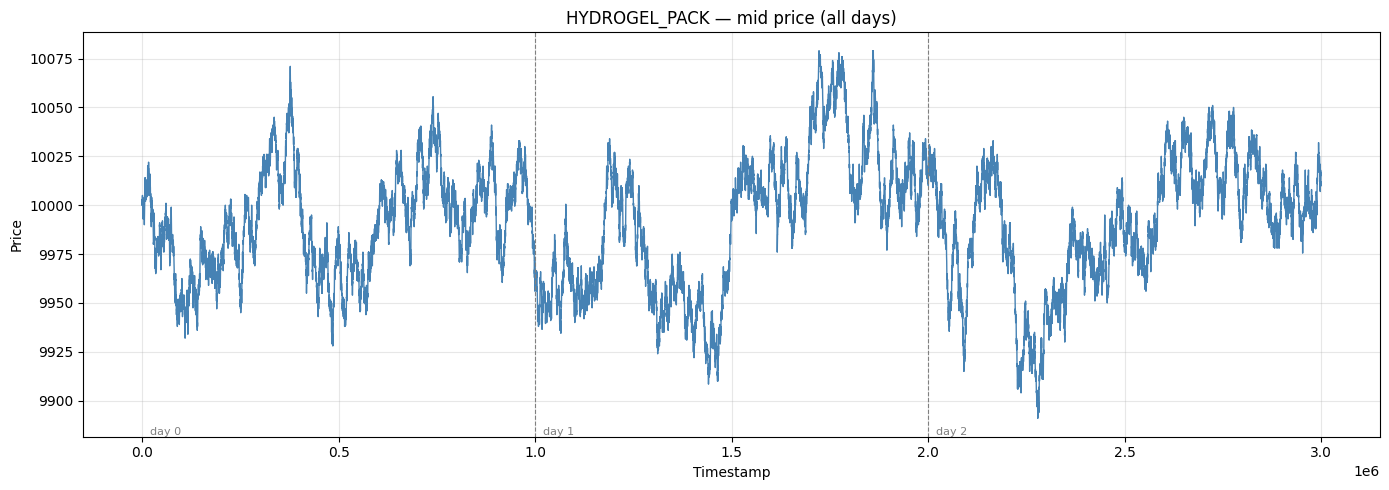

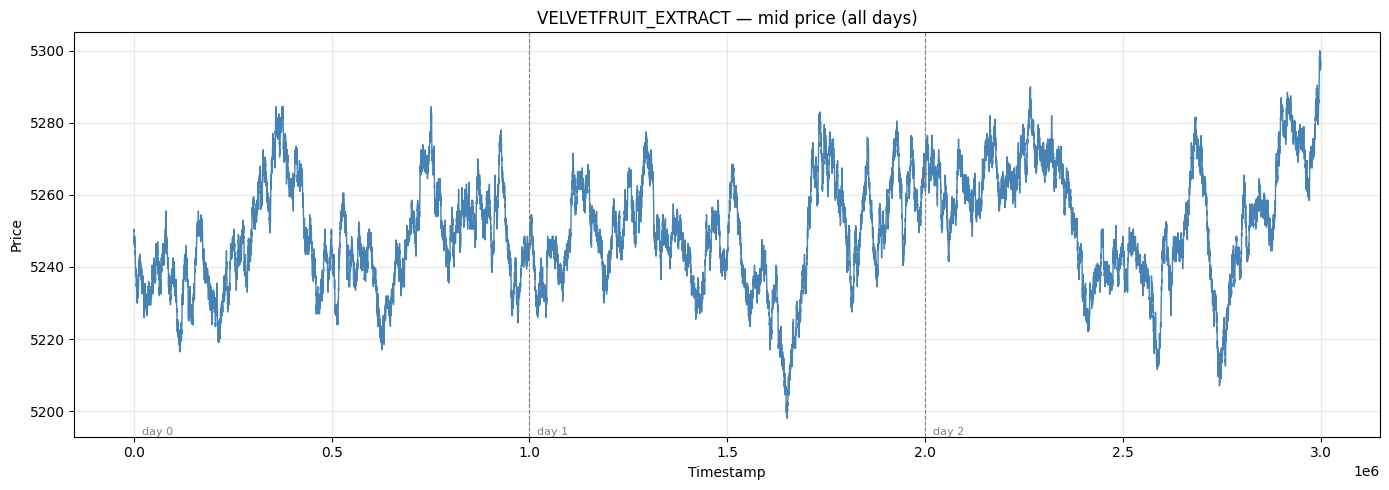

In [8]:
def plot_prices(prices_df, title=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(prices_df['timestamp'], prices_df['mid_price'], lw=1.0, color='steelblue')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.8, ls='--')
    for i, lbl in enumerate(['day 0', 'day 1', 'day 2']):
        ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], lbl, fontsize=8, color='gray', va='bottom')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Price')
    ax.set_title(title or 'Mid Price'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_prices(hp_prices,  'HYDROGEL_PACK — mid price (all days)')
plot_prices(vfe_prices, 'VELVETFRUIT_EXTRACT — mid price (all days)')

In [51]:
vfe_prices.describe()

,timestamp,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,mid_price
count,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,1.499950e+06,5247.604033,37.825300,5252.592167,37.801133,5250.098100
std,8.660398e+05,15.625850,21.016731,15.646450,21.054918,15.630415
min,0.000000e+00,5195.000000,1.000000,5201.000000,1.000000,5198.000000
25%,7.499750e+05,5236.000000,19.000000,5241.000000,19.000000,5238.500000
50%,1.499950e+06,5247.000000,25.000000,5252.000000,25.000000,5249.500000
75%,2.249925e+06,5260.000000,59.000000,5265.000000,59.000000,5262.500000
max,2.999900e+06,5298.000000,75.000000,5302.000000,75.000000,5300.000000


In [32]:
def run_time_series_suite(series, label=''):
    clean = series.dropna()
    results = {}

    adf = adfuller(clean)
    results['ADF (Stationarity)'] = {'p-value': adf[1], 'Stationary': adf[1] < 0.05}

    kpss_res = kpss(clean, regression='c', nlags='auto')
    results['KPSS (Trend Stationary)'] = {'p-value': kpss_res[1], 'Stationary': kpss_res[1] > 0.05}

    lb = acorr_ljungbox(clean, lags=[10], return_df=True)
    results['Ljung-Box (White Noise)'] = {'p-value': lb['lb_pvalue'].values[0], 'Is White Noise': lb['lb_pvalue'].values[0] > 0.05}

    results['Descriptive'] = {
        'Mean': clean.mean(), 'Std Dev': clean.std(),
        'Skewness': clean.skew(), 'Kurtosis': clean.kurt()
    }
    if label:
        print(f'=== {label} ===')
    return results

print(run_time_series_suite(hp_prices['mid_price'],  'HYDROGEL_PACK'))
print()
print(run_time_series_suite(vfe_prices['mid_price'], 'VELVETFRUIT_EXTRACT'))

/var/folders/v2/8kmltg8j0d1glmqdfvfvmprc0000gn/T/ipykernel_47975/3302918956.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(clean, regression='c', nlags='auto')


=== HYDROGEL_PACK ===
{'ADF (Stationarity)': {'p-value': np.float64(1.0685013541265121e-05), 'Stationary': np.True_}, 'KPSS (Trend Stationary)': {'p-value': np.float64(0.01), 'Stationary': np.False_}, 'Ljung-Box (White Noise)': {'p-value': np.float64(0.0), 'Is White Noise': np.False_}, 'Descriptive': {'Mean': np.float64(9990.806866666666), 'Std Dev': np.float64(31.935213763359915), 'Skewness': np.float64(-0.11156613283797445), 'Kurtosis': np.float64(-0.30964324651979336)}}

=== VELVETFRUIT_EXTRACT ===
{'ADF (Stationarity)': {'p-value': np.float64(4.71184967017108e-05), 'Stationary': np.True_}, 'KPSS (Trend Stationary)': {'p-value': np.float64(0.01), 'Stationary': np.False_}, 'Ljung-Box (White Noise)': {'p-value': np.float64(0.0), 'Is White Noise': np.False_}, 'Descriptive': {'Mean': np.float64(5250.0981), 'Std Dev': np.float64(15.630415436563332), 'Skewness': np.float64(-0.012266349826192366), 'Kurtosis': np.float64(-0.3808436282317995)}}


/var/folders/v2/8kmltg8j0d1glmqdfvfvmprc0000gn/T/ipykernel_47975/3302918956.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(clean, regression='c', nlags='auto')


In [37]:
def run_advanced_series_suite(series, label=''):
    clean = series.dropna()
    results = {}

    try:
        H, c, _ = compute_Hc(clean, kind='price', simplified=True)
        results['Hurst Exponent'] = {
            'Value': H,
            'Interpretation': 'Mean-Reverting' if H < 0.45 else 'Trending' if H > 0.55 else 'Martingale/Random Walk'
        }
    except FloatingPointError:
        results['Hurst Exponent'] = {'Value': None, 'Interpretation': 'Computation Failed (div0)'}

    vr = VarianceRatio(clean)
    results['Variance Ratio (Martingale)'] = {'p-value': vr.pvalue, 'Is Random Walk': vr.pvalue > 0.05}

    kurt = stats.kurtosis(clean)
    results['Volatility Profile'] = {'Excess Kurtosis': kurt, 'Has Fat Tails': kurt > 1, 'Std Dev': clean.std()}

    if label:
        print(f'=== {label} ===')
    return results

print(run_advanced_series_suite(hp_prices['mid_price'],  'HYDROGEL_PACK'))
print()
print(run_advanced_series_suite(vfe_prices['mid_price'], 'VELVETFRUIT_EXTRACT'))

=== HYDROGEL_PACK ===
{'Hurst Exponent': {'Value': np.float64(0.40256005393890143), 'Interpretation': 'Mean-Reverting'}, 'Variance Ratio (Martingale)': {'p-value': np.float64(0.0), 'Is Random Walk': np.False_}, 'Volatility Profile': {'Excess Kurtosis': np.float64(-0.3097916350538741), 'Has Fat Tails': np.False_, 'Std Dev': np.float64(31.935213763359915)}}

=== VELVETFRUIT_EXTRACT ===
{'Hurst Exponent': {'Value': np.float64(0.4083295704515039), 'Interpretation': 'Mean-Reverting'}, 'Variance Ratio (Martingale)': {'p-value': np.float64(0.0), 'Is Random Walk': np.False_}, 'Volatility Profile': {'Excess Kurtosis': np.float64(-0.3809801505893624), 'Has Fat Tails': np.False_, 'Std Dev': np.float64(15.630415436563332)}}


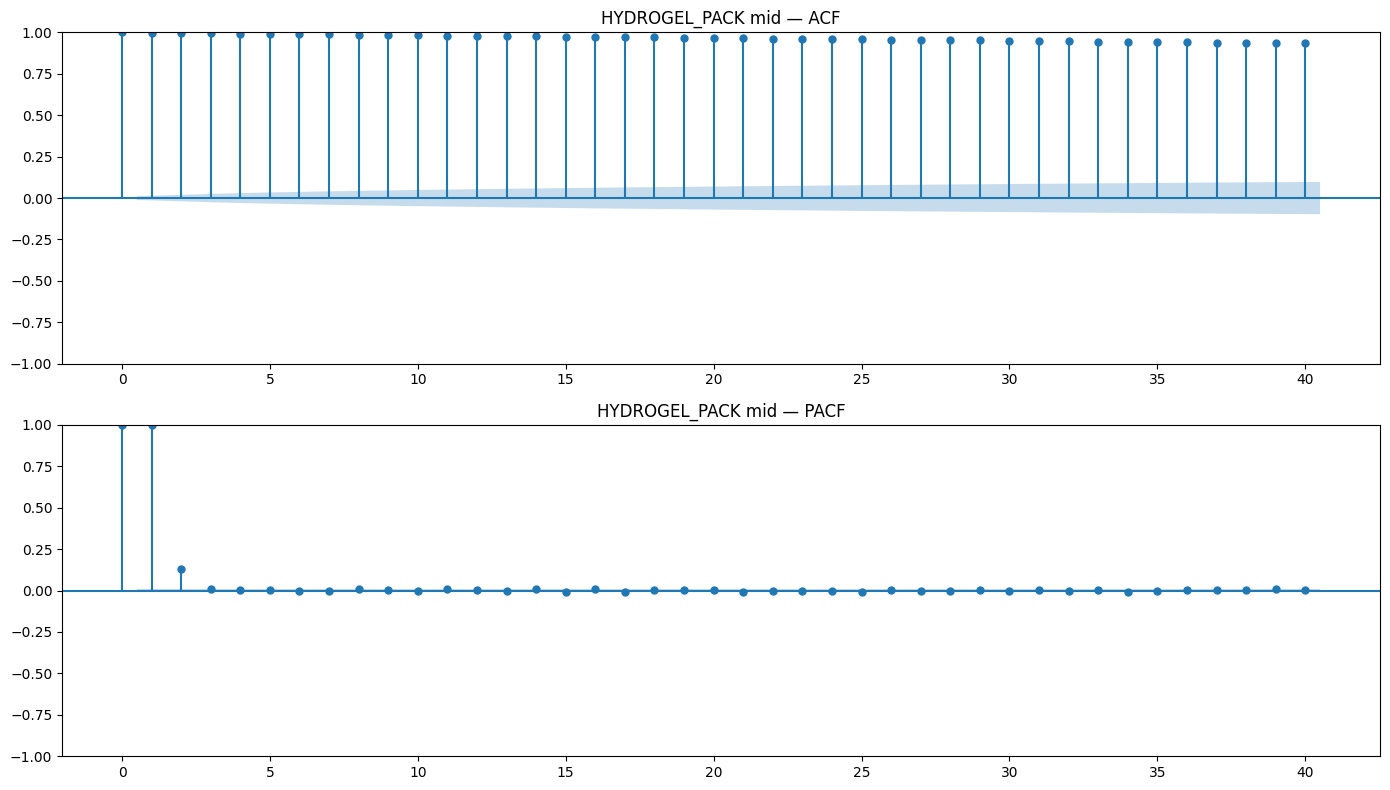

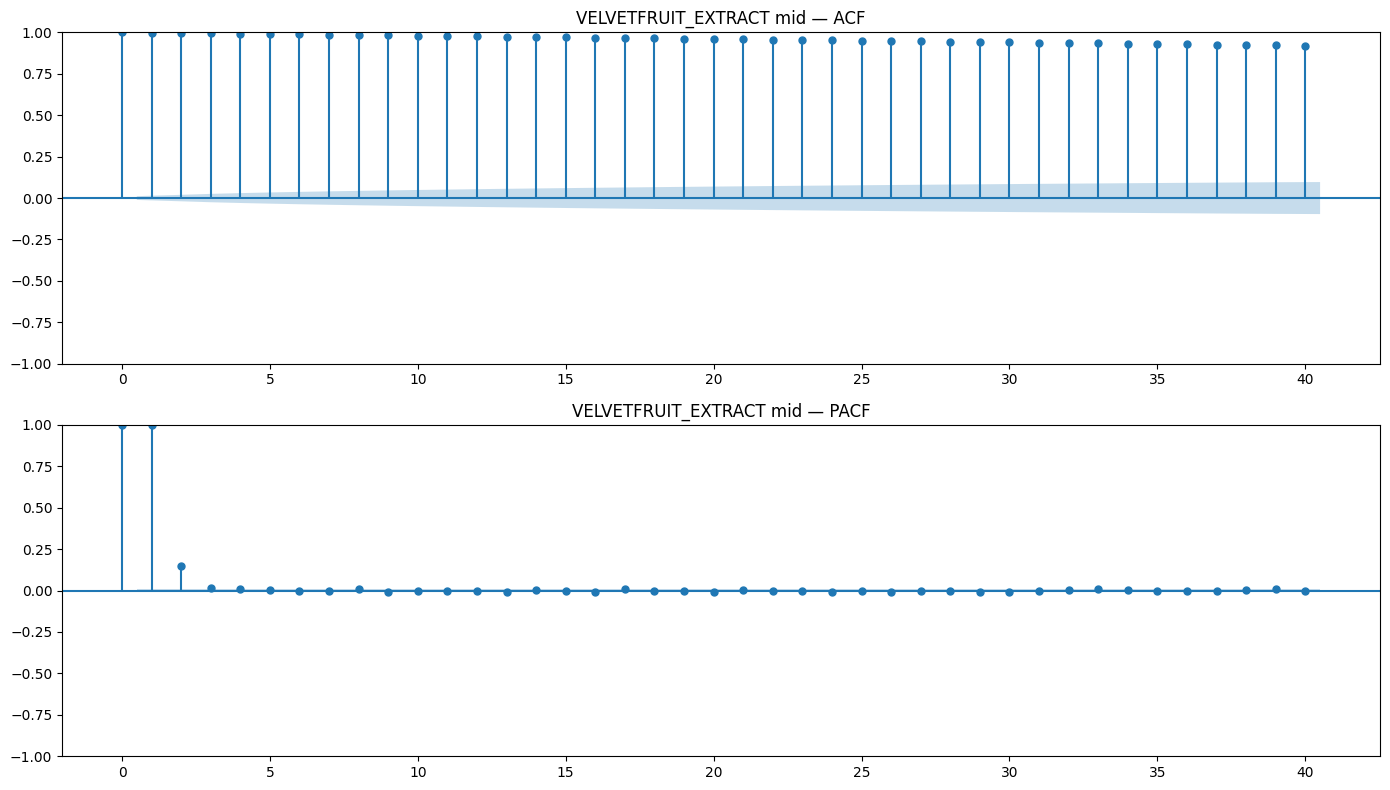

In [19]:
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    plot_acf( df['mid_price'].dropna(), lags=40, ax=axes[0], title=f'{label} mid — ACF')
    plot_pacf(df['mid_price'].dropna(), lags=40, ax=axes[1], title=f'{label} mid — PACF')
    plt.tight_layout(); plt.show()

Linear Regression on VELVETFRUIT_EXTRACT mid price:
  Coefficients: 0.8404, Intercept: 10.7271, R²: 0.9949


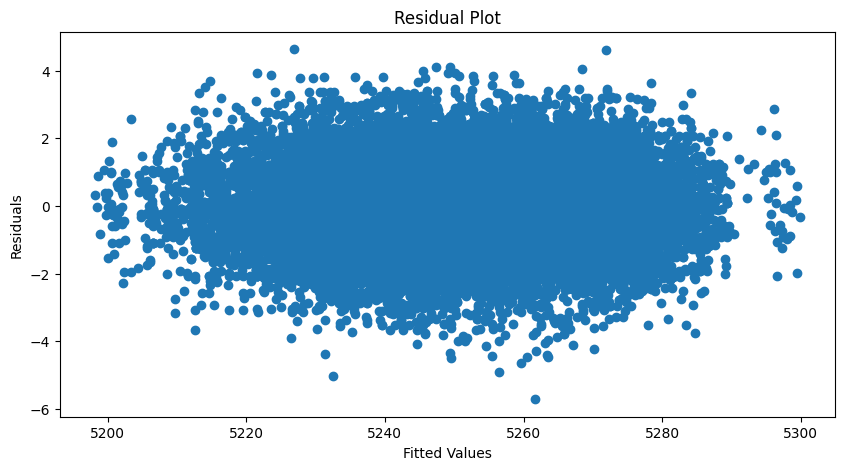

In [45]:
x2 = vfe_prices['mid_price'].shift(2)[2:]
x1 = vfe_prices['mid_price'].shift(1)[2:]
y = vfe_prices['mid_price'][2:]
model = LinearRegression().fit(np.column_stack([x1, x2]), y.values)
print(f'Linear Regression on VELVETFRUIT_EXTRACT mid price:\n  Coefficients: {model.coef_[0]:.4f}, Intercept: {model.intercept_:.4f}, R²: {model.score(np.column_stack([x1, x2]), y.values):.4f}')
residuals = y - model.predict(np.column_stack([x1, x2]))
# Plot residuals vs fitted
plt.figure(figsize=(10, 5)) 
plt.scatter(model.predict(np.column_stack([x1, x2])), residuals)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

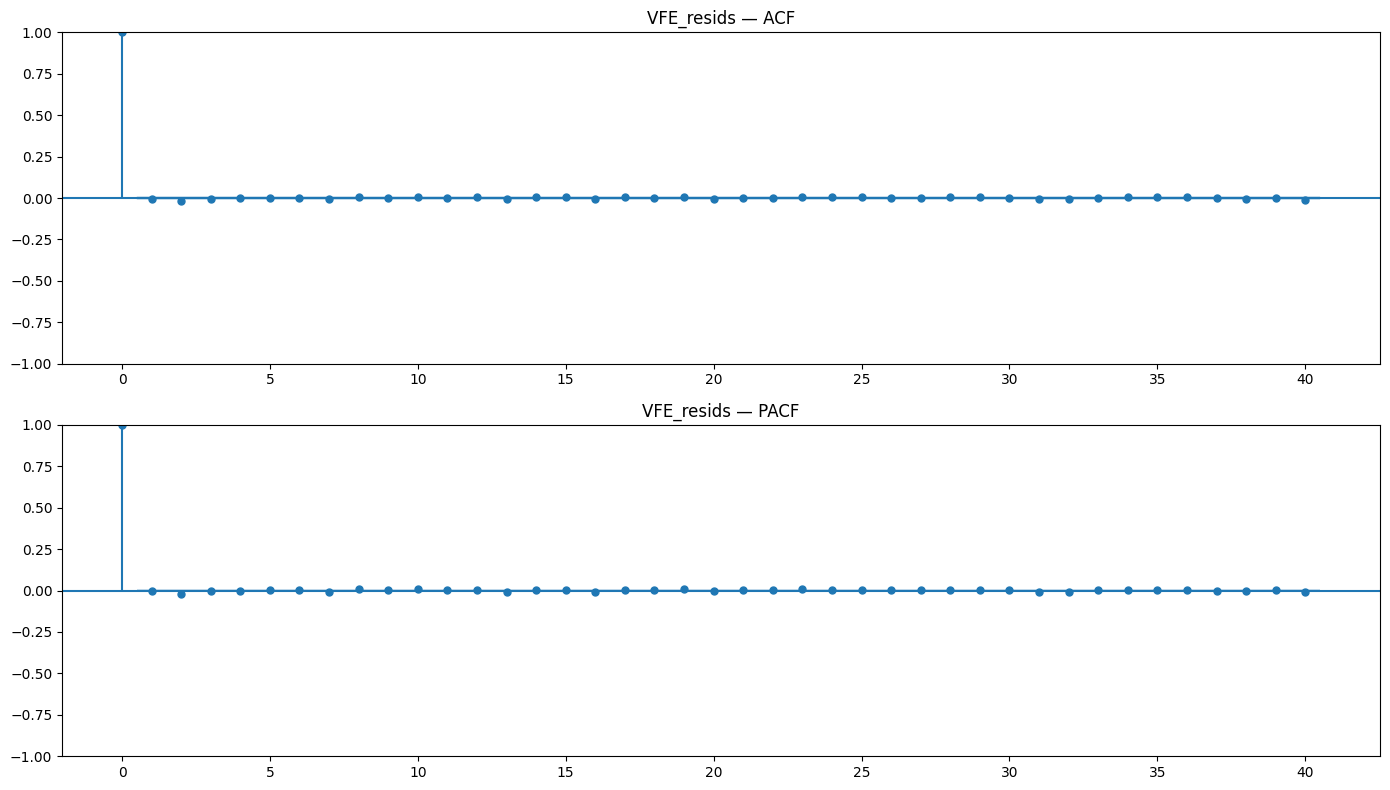

In [41]:
#print(run_time_series_suite(residuals, 'VELVETFRUIT_EXTRACT Linear Regression Residuals'))
#print(run_advanced_series_suite(residuals, 'VELVETFRUIT_EXTRACT Linear Regression Residuals'))
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(residuals, lags=40, ax=axes[0], title=f'{label} — ACF')
plot_pacf(residuals, lags=40, ax=axes[1], title=f'{label} — PACF')
plt.tight_layout(); plt.show()

In [55]:
beta1, beta2, alpha = model.coef_[0], model.coef_[1], model.intercept_
print(alpha, beta1, beta2)
print(alpha / (1 - beta1 - beta2))

10.727097081004104 0.840361578360772 0.15759553490214856
5250.950474297776


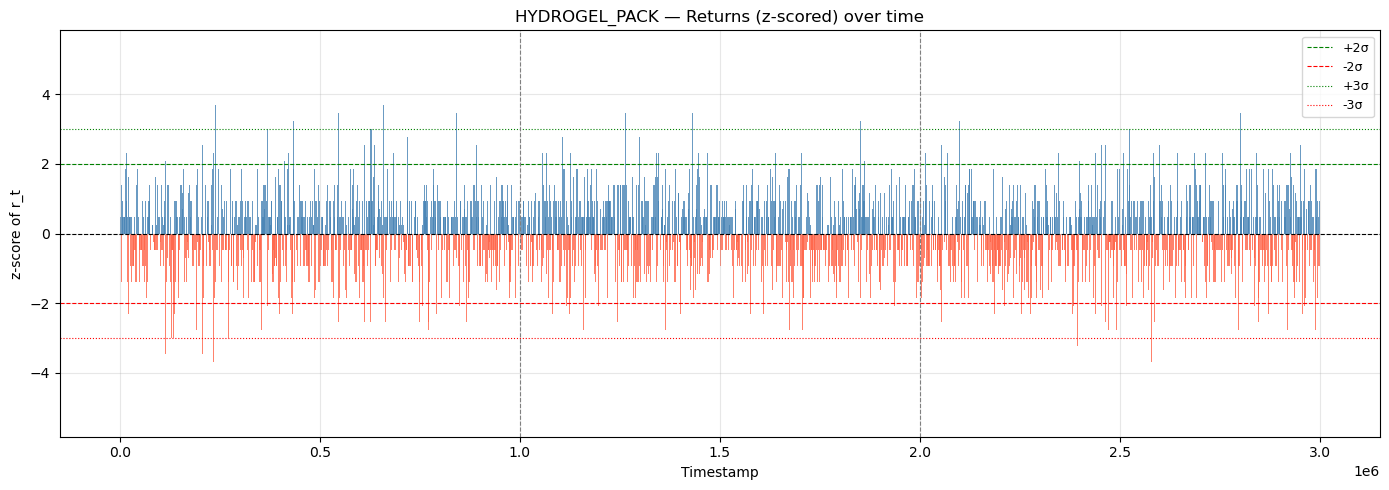

HYDROGEL_PACK: mu=0.0003  sigma=2.1699
  Non-zero returns: 24594 / 30000  (82.0%)
  % |z| > 2: 4.6%
  % |z| > 3: 0.5%



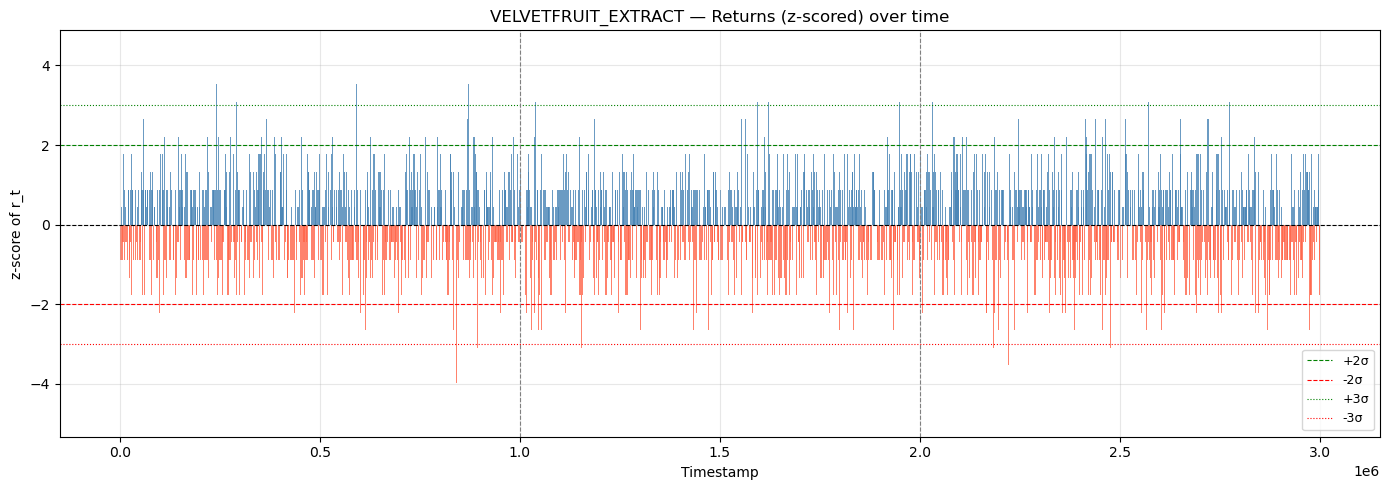

VELVETFRUIT_EXTRACT: mu=0.0015  sigma=1.1312
  Non-zero returns: 22600 / 30000  (75.3%)
  % |z| > 2: 4.3%
  % |z| > 3: 0.7%



In [6]:
# Returns z-scored over time
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    r   = df['mid_price'].diff()
    ts  = df['timestamp']
    mu_r, sig_r = r.mean(), r.std()
    z_r = (r - mu_r) / sig_r

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['steelblue' if v >= 0 else 'tomato' for v in z_r.fillna(0)]
    ax.bar(ts, z_r, width=200, color=colors, alpha=0.8)
    for h, col, ls, lbl in [(2,'green','--','+2σ'),(-2,'red','--','-2σ'),(3,'green',':','+3σ'),(-3,'red',':','-3σ')]:
        ax.axhline(h, color=col, lw=0.8, ls=ls, label=lbl)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('z-score of r_t')
    ax.set_title(f'{label} — Returns (z-scored) over time')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'{label}: mu={mu_r:.4f}  sigma={sig_r:.4f}')
    print(f'  Non-zero returns: {(r != 0).sum()} / {len(r)}  ({(r != 0).mean()*100:.1f}%)')
    print(f'  % |z| > 2: {(z_r.abs() > 2).mean()*100:.1f}%')
    print(f'  % |z| > 3: {(z_r.abs() > 3).mean()*100:.1f}%')
    print()

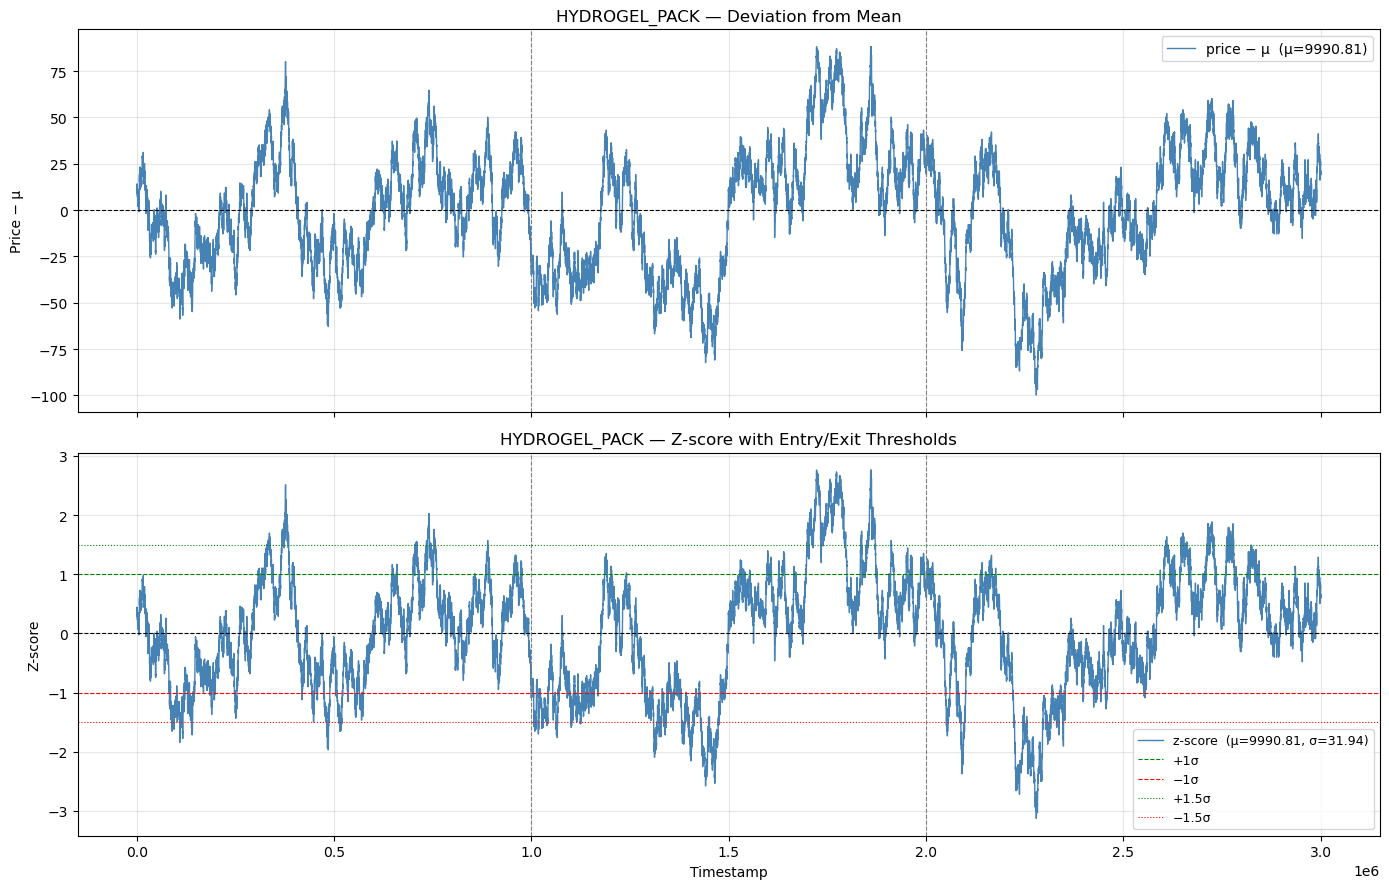

HYDROGEL_PACK: μ=9990.8069  σ=31.9352
  % |z| > 1.0: 33.2%
  % |z| > 1.5: 12.4%



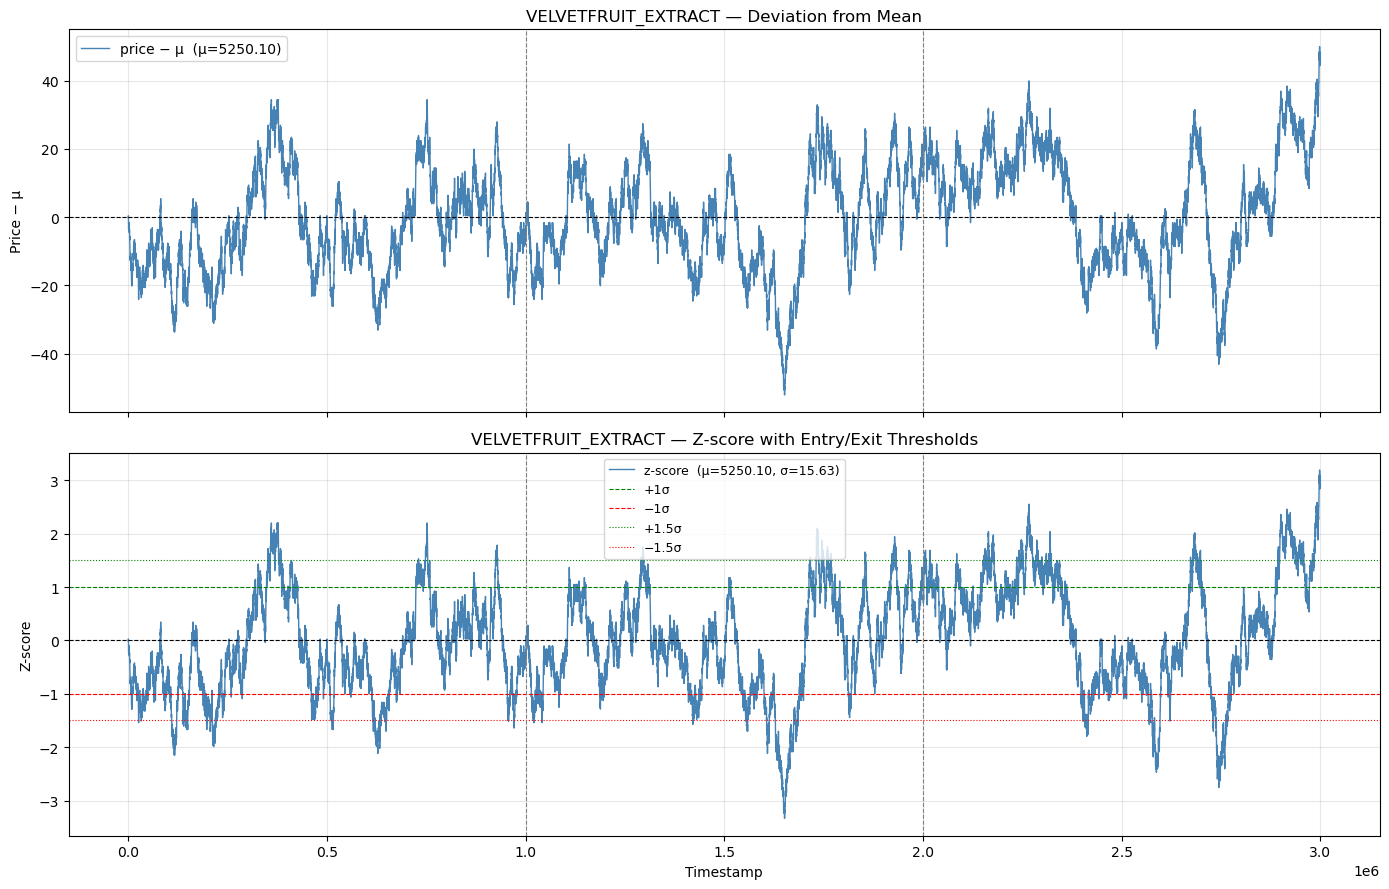

VELVETFRUIT_EXTRACT: μ=5250.0981  σ=15.6304
  % |z| > 1.0: 33.3%
  % |z| > 1.5: 12.1%



In [7]:
# Deviation from mean + z-score with entry/exit thresholds
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    mu    = df['mid_price'].mean()
    sigma = df['mid_price'].std()
    z     = (df['mid_price'] - mu) / sigma

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    ax1.plot(df['timestamp'], df['mid_price'] - mu, lw=1.0, color='steelblue', label=f'price − μ  (μ={mu:.2f})')
    ax1.axhline(0, color='black', lw=0.8, ls='--')
    for sep in [1_000_000, 2_000_000]:
        ax1.axvline(sep, color='gray', lw=0.8, ls='--')
    ax1.set_ylabel('Price − μ'); ax1.set_title(f'{label} — Deviation from Mean')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(df['timestamp'], z, lw=1.0, color='steelblue', label=f'z-score  (μ={mu:.2f}, σ={sigma:.2f})')
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    for h, col, ls, lbl in [(1,'green','--','+1σ'),(-1,'red','--','−1σ'),(1.5,'green',':','+1.5σ'),(-1.5,'red',':','−1.5σ')]:
        ax2.axhline(h, color=col, lw=0.8, ls=ls, label=lbl)
    for sep in [1_000_000, 2_000_000]:
        ax2.axvline(sep, color='gray', lw=0.8, ls='--')
    ax2.set_xlabel('Timestamp'); ax2.set_ylabel('Z-score')
    ax2.set_title(f'{label} — Z-score with Entry/Exit Thresholds')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f'{label}: μ={mu:.4f}  σ={sigma:.4f}')
    print(f'  % |z| > 1.0: {(z.abs() > 1.0).mean()*100:.1f}%')
    print(f'  % |z| > 1.5: {(z.abs() > 1.5).mean()*100:.1f}%')
    print()

HYDROGEL_PACK  KS stat=0.0491  p=2.6275e-63  Normal: False


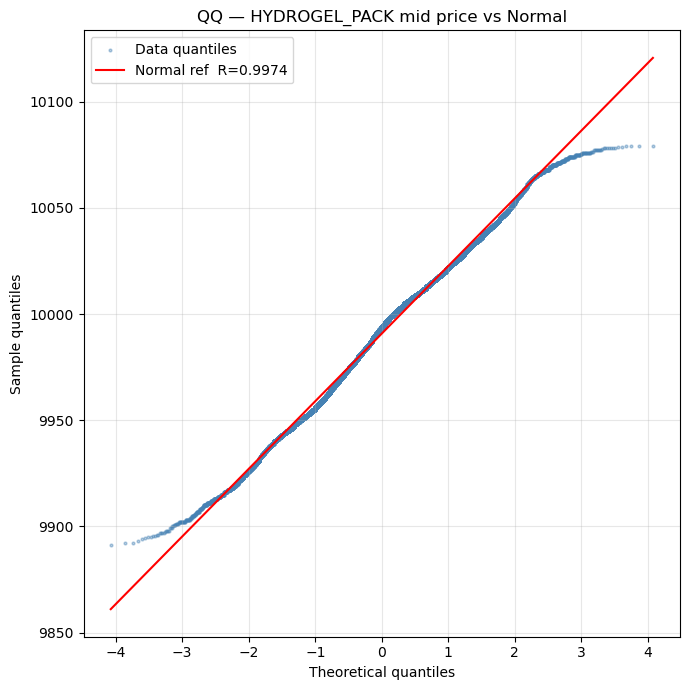

VELVETFRUIT_EXTRACT  KS stat=0.0403  p=1.1186e-42  Normal: False


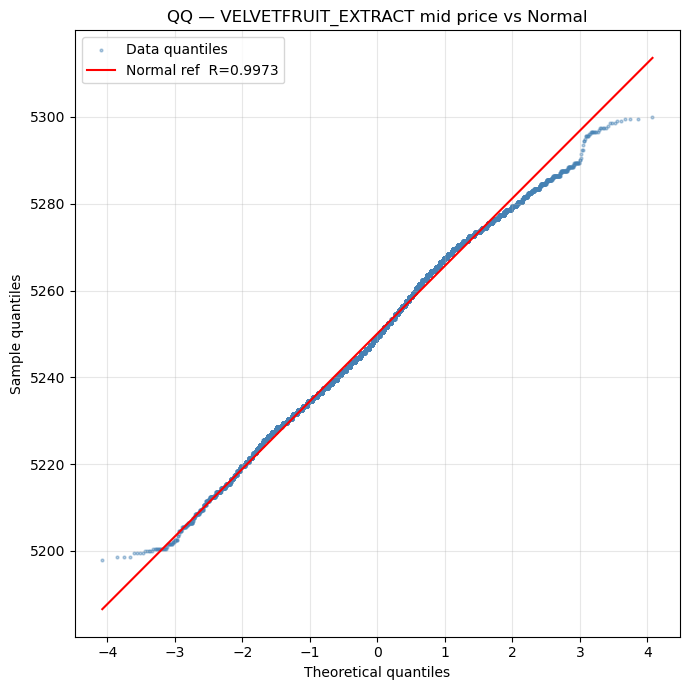

In [8]:
# KS test + QQ plot — normality of mid price levels
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    clean = df['mid_price'].dropna()
    mu_v, sig_v = clean.mean(), clean.std()
    ks_stat, ks_p = stats.kstest(clean, 'norm', args=(mu_v, sig_v))
    print(f'{label}  KS stat={ks_stat:.4f}  p={ks_p:.4e}  Normal: {ks_p > 0.05}')

    fig, ax = plt.subplots(figsize=(7, 7))
    (osm, osr), (slope, intercept, r) = stats.probplot(clean, dist='norm', plot=None)
    ax.scatter(osm, osr, s=4, alpha=0.4, color='steelblue', label='Data quantiles')
    lx = np.array([osm.min(), osm.max()])
    ax.plot(lx, slope * lx + intercept, color='red', lw=1.5, label=f'Normal ref  R={r:.4f}')
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
    ax.set_title(f'QQ — {label} mid price vs Normal')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

HYDROGEL_PACK: n=29998  lag-1 corr φ=-0.1292


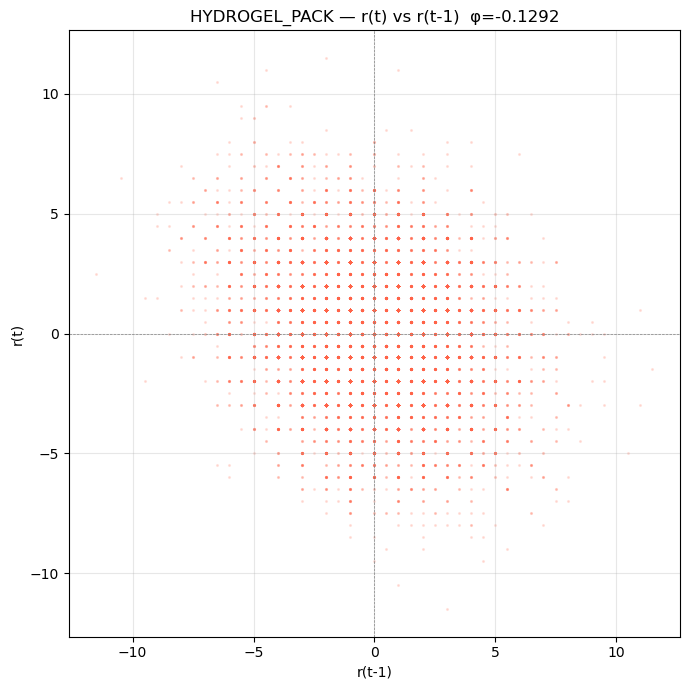

VELVETFRUIT_EXTRACT: n=29998  lag-1 corr φ=-0.1587


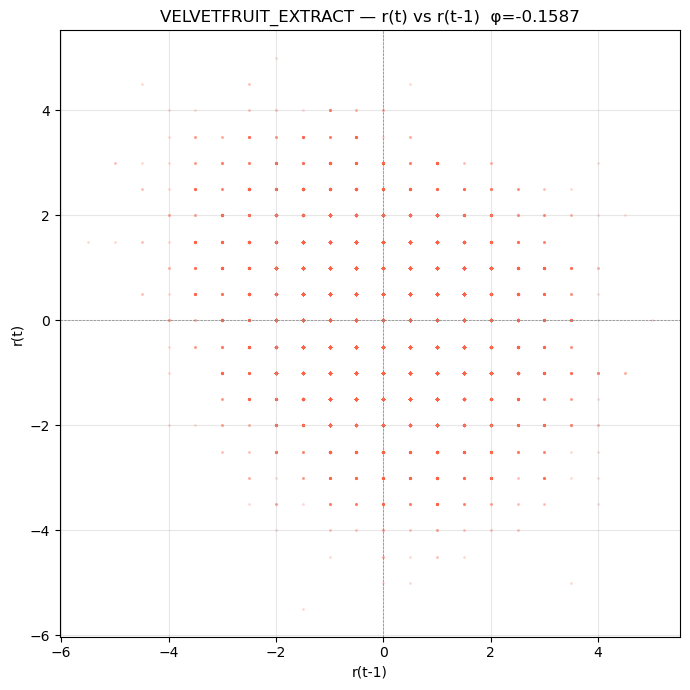

In [9]:
# Bivariate returns: r(t) vs r(t-1)
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    r   = df['mid_price'].dropna().reset_index(drop=True).diff().dropna()
    biv = pd.DataFrame({'r(t)': r.values[1:], 'r(t-1)': r.values[:-1]})
    phi = biv.corr().iloc[0, 1]
    print(f'{label}: n={len(biv)}  lag-1 corr φ={phi:.4f}')

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(biv['r(t-1)'], biv['r(t)'], s=1.5, alpha=0.15, color='tomato')
    ax.axhline(0, color='gray', lw=0.5, ls='--'); ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('r(t-1)'); ax.set_ylabel('r(t)')
    ax.set_title(f'{label} — r(t) vs r(t-1)  φ={phi:.4f}')
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

HYDROGEL_PACK: n=29999  φ=0.9977
  P(t): KS p=2.877e-63  SW p=1.858e-29  non-normal
  P(t-1): KS p=2.802e-63  SW p=1.918e-29  non-normal
  Mardia skew: b1p=0.0133  Chi²=66.60  p=1.187e-13  fail
  Mardia kurt: b2p=8.2589  z=5.61  p=2.075e-08  fail


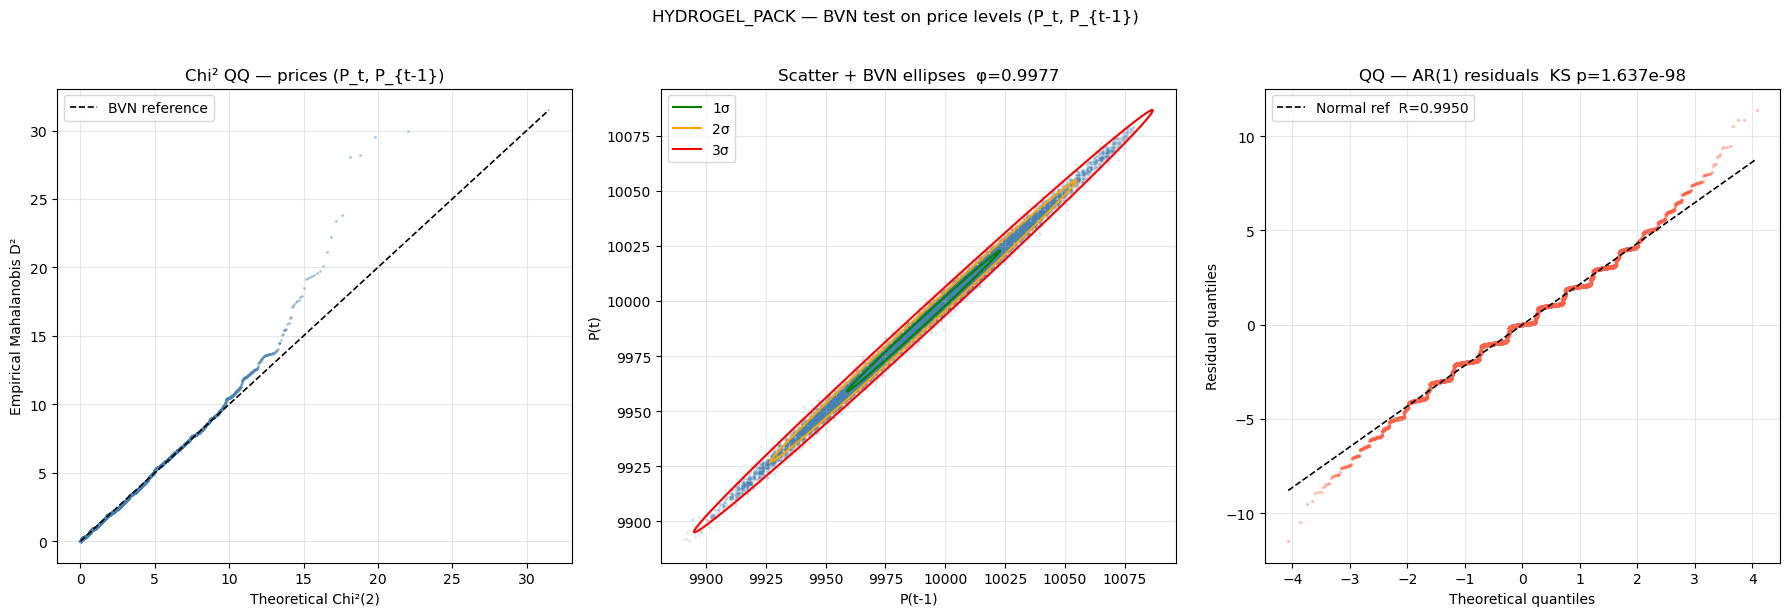


VELVETFRUIT_EXTRACT: n=29999  φ=0.9974
  P(t): KS p=1.048e-42  SW p=2.484e-39  non-normal
  P(t-1): KS p=1.161e-42  SW p=2.489e-39  non-normal
  Mardia skew: b1p=0.0013  Chi²=6.71  p=1.522e-01  pass
  Mardia kurt: b2p=7.9654  z=-0.75  p=4.534e-01  pass


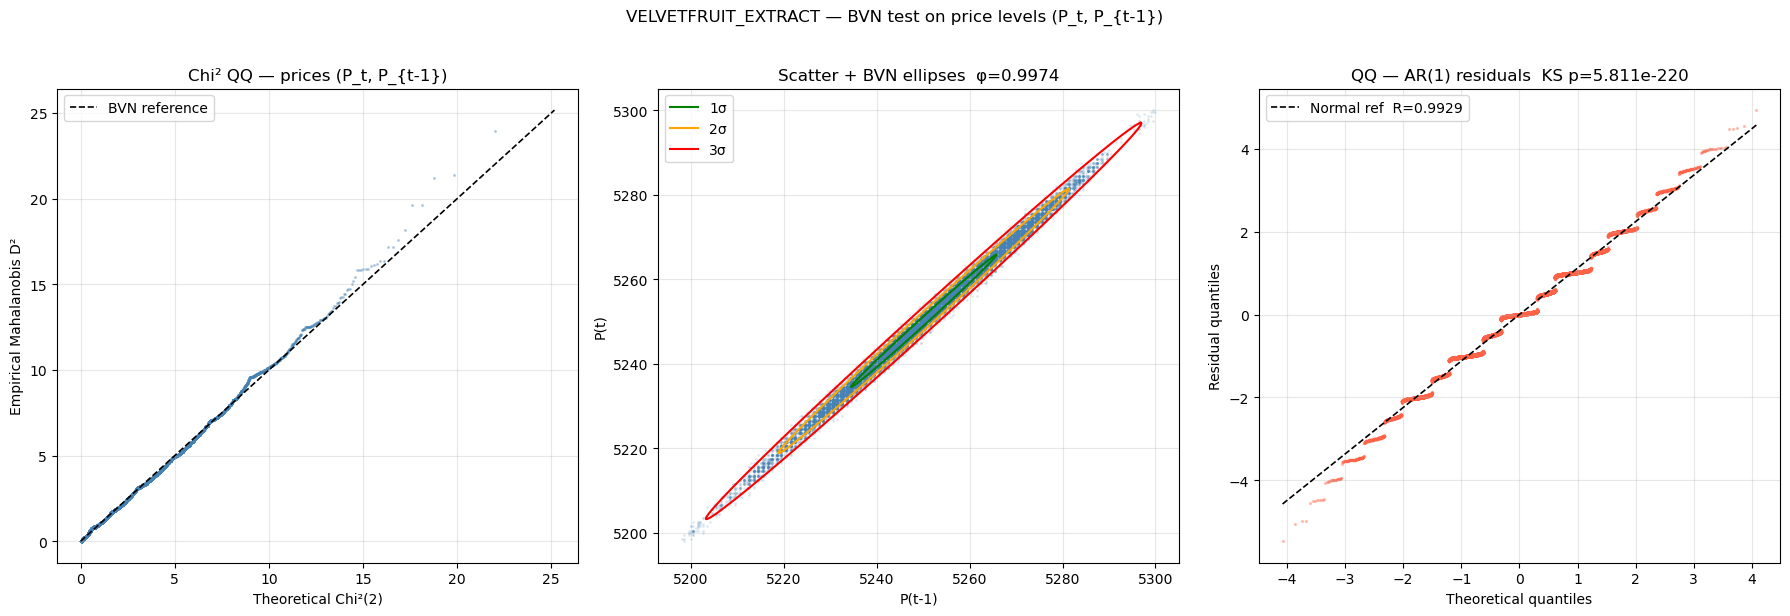

In [10]:
# BVN test on (P_t, P_{t-1}) — AR(1) structure in price levels
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    p = df['mid_price'].dropna().reset_index(drop=True)
    price_biv = pd.DataFrame({'P(t)': p.values[1:], 'P(t-1)': p.values[:-1]})
    n_p = len(price_biv)
    phi_hat = price_biv.corr().iloc[0, 1]
    print(f'{label}: n={n_p}  φ={phi_hat:.4f}')

    for col in ['P(t)', 'P(t-1)']:
        v = price_biv[col].values
        ks_s, ks_p = stats.kstest(v, 'norm', args=(v.mean(), v.std()))
        sw_s, sw_p = stats.shapiro(v[:4999])
        print(f'  {col}: KS p={ks_p:.3e}  SW p={sw_p:.3e}  {"normal" if ks_p>0.05 and sw_p>0.05 else "non-normal"}')

    X_p  = price_biv.values
    X_pc = X_p - X_p.mean(axis=0)
    S_p  = np.cov(X_p.T)
    S_pi = np.linalg.inv(S_p)
    D_p  = X_pc @ S_pi @ X_pc.T

    b1p_p  = (D_p**3).mean()
    chi2_s = n_p * b1p_p / 6
    p_s    = 1 - stats.chi2.cdf(chi2_s, df=4)
    b2p_p  = np.mean(np.diag(D_p)**2)
    z_k    = (b2p_p - 8) / np.sqrt(64 / n_p)
    p_k    = 2 * (1 - stats.norm.cdf(abs(z_k)))
    print(f"  Mardia skew: b1p={b1p_p:.4f}  Chi²={chi2_s:.2f}  p={p_s:.3e}  {'pass' if p_s>0.05 else 'fail'}")
    print(f"  Mardia kurt: b2p={b2p_p:.4f}  z={z_k:.2f}  p={p_k:.3e}  {'pass' if p_k>0.05 else 'fail'}")

    D2_p   = np.sort(np.diag(D_p))
    chi2_q = stats.chi2.ppf((np.arange(1, n_p+1) - 0.5) / n_p, df=2)
    L_p    = np.linalg.cholesky(S_p)
    mu_p2  = X_p.mean(axis=0)
    theta  = np.linspace(0, 2*np.pi, 300)
    circle = np.stack([np.cos(theta), np.sin(theta)])

    mu_fit = price_biv['P(t)'].mean()
    resid  = price_biv['P(t)'].values - (mu_fit + phi_hat * (price_biv['P(t-1)'].values - mu_fit))
    ks_r, ks_rp = stats.kstest(resid, 'norm', args=(resid.mean(), resid.std()))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    ax = axes[0]
    ax.scatter(chi2_q, D2_p, s=1.5, alpha=0.3, color='steelblue')
    lim = max(chi2_q.max(), D2_p.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='BVN reference')
    ax.set_xlabel('Theoretical Chi²(2)'); ax.set_ylabel('Empirical Mahalanobis D²')
    ax.set_title('Chi² QQ — prices (P_t, P_{t-1})'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.scatter(price_biv['P(t-1)'], price_biv['P(t)'], s=1.5, alpha=0.1, color='steelblue')
    for nsig, col, lbl in [(1,'green','1σ'),(2,'orange','2σ'),(3,'red','3σ')]:
        e = mu_p2[:, None] + nsig * L_p @ circle
        ax.plot(e[1], e[0], color=col, lw=1.5, label=lbl)
    ax.set_xlabel('P(t-1)'); ax.set_ylabel('P(t)')
    ax.set_title(f'Scatter + BVN ellipses  φ={phi_hat:.4f}'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    (osm_r, osr_r), (sl_r, ic_r, rv_r) = stats.probplot(resid, dist='norm', plot=None)
    ax.scatter(osm_r, osr_r, s=2, alpha=0.3, color='tomato')
    lx = np.array([osm_r.min(), osm_r.max()])
    ax.plot(lx, sl_r*lx+ic_r, 'k--', lw=1.2, label=f'Normal ref  R={rv_r:.4f}')
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Residual quantiles')
    ax.set_title(f'QQ — AR(1) residuals  KS p={ks_rp:.3e}'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'{label} — BVN test on price levels (P_t, P_{{t-1}})', y=1.02)
    plt.tight_layout(); plt.show()
    print()

HYDROGEL_PACK: μ=0.0003  σ=2.1698  KS p=1.761e-212  Normal: False


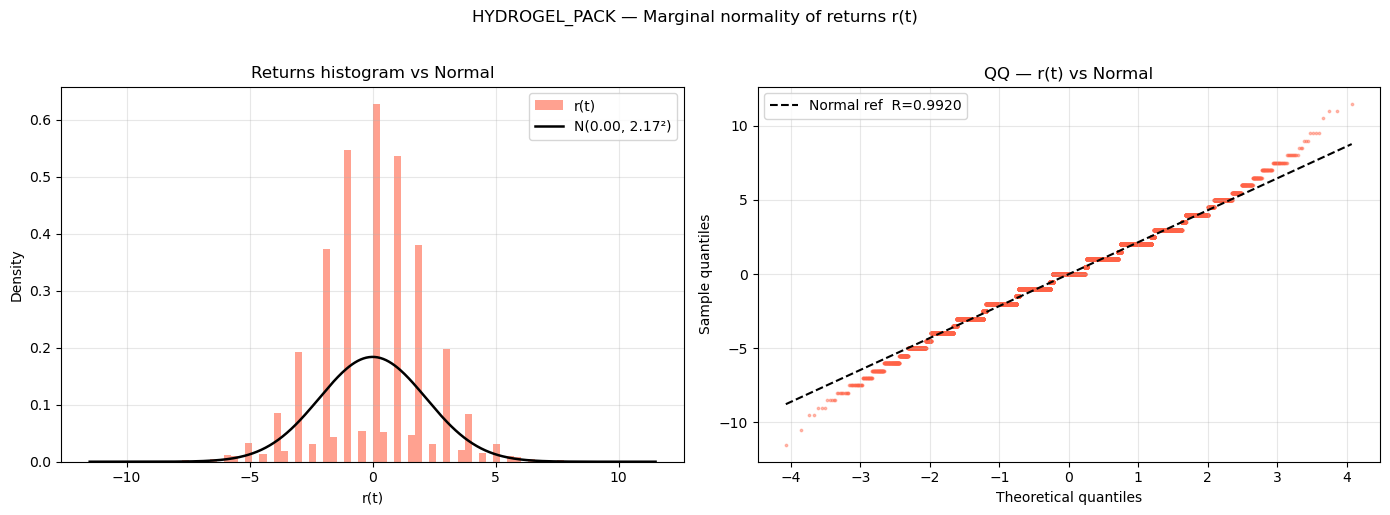

VELVETFRUIT_EXTRACT: μ=0.0015  σ=1.1312  KS p=0.000e+00  Normal: False


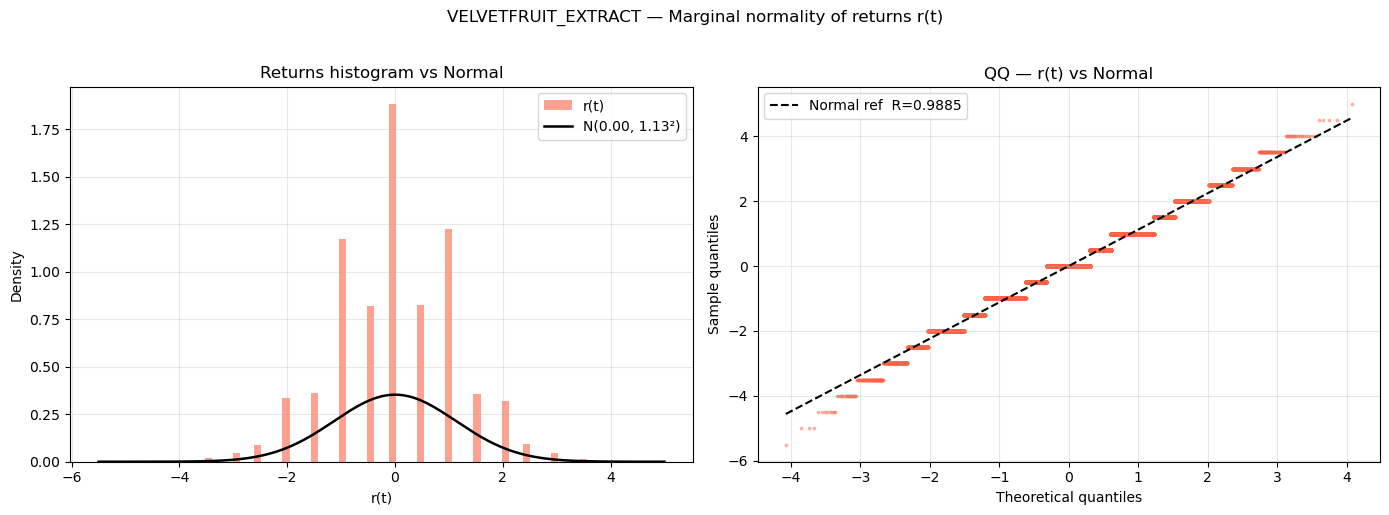

In [11]:
# Marginal normality of returns r(t)
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    r_clean = df['mid_price'].dropna().diff().dropna().values
    mu_r, sig_r = r_clean.mean(), r_clean.std()
    ks_stat, ks_p = stats.kstest(r_clean, 'norm', args=(mu_r, sig_r))
    print(f'{label}: μ={mu_r:.4f}  σ={sig_r:.4f}  KS p={ks_p:.3e}  Normal: {ks_p > 0.05}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    counts, bins, _ = ax.hist(r_clean, bins=80, density=True, color='tomato', alpha=0.6, label='r(t)')
    x_fit = np.linspace(bins[0], bins[-1], 400)
    ax.plot(x_fit, stats.norm.pdf(x_fit, mu_r, sig_r), 'k-', lw=1.8, label=f'N({mu_r:.2f}, {sig_r:.2f}²)')
    ax.set_xlabel('r(t)'); ax.set_ylabel('Density')
    ax.set_title('Returns histogram vs Normal'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    (osm, osr), (slope, intercept, r_val) = stats.probplot(r_clean, dist='norm', plot=None)
    ax.scatter(osm, osr, s=3, alpha=0.4, color='tomato')
    lx = np.array([osm.min(), osm.max()])
    ax.plot(lx, slope*lx+intercept, 'k--', lw=1.5, label=f'Normal ref  R={r_val:.4f}')
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
    ax.set_title('QQ — r(t) vs Normal'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'{label} — Marginal normality of returns r(t)', y=1.02)
    plt.tight_layout(); plt.show()

=== HYDROGEL_PACK (n=29998) ===
Combination                    SW stat        SW p   KS stat        KS p  Normal?
--------------------------------------------------------------------------------
r(t)                            0.9835   1.056e-23    0.0901  2.076e-212  no
r(t-1)                          0.9841   2.505e-23    0.0901  1.545e-212  no
r(t) + r(t-1)                   0.9921   4.771e-16    0.0655  2.416e-112  no
r(t) - r(t-1)                   0.9876   1.389e-20    0.0673  1.969e-118  no
r(t) + 2·r(t-1)                 0.9964   1.187e-09    0.0424   2.742e-47  no
2·r(t) - r(t-1)                 0.9917   1.451e-16    0.0474   4.929e-59  no
r(t) + 0.5·r(t-1)               0.9965   1.684e-09    0.0403   9.116e-43  no
0.5·r(t) - r(t-1)               0.9924   1.187e-15    0.0478   4.572e-60  no


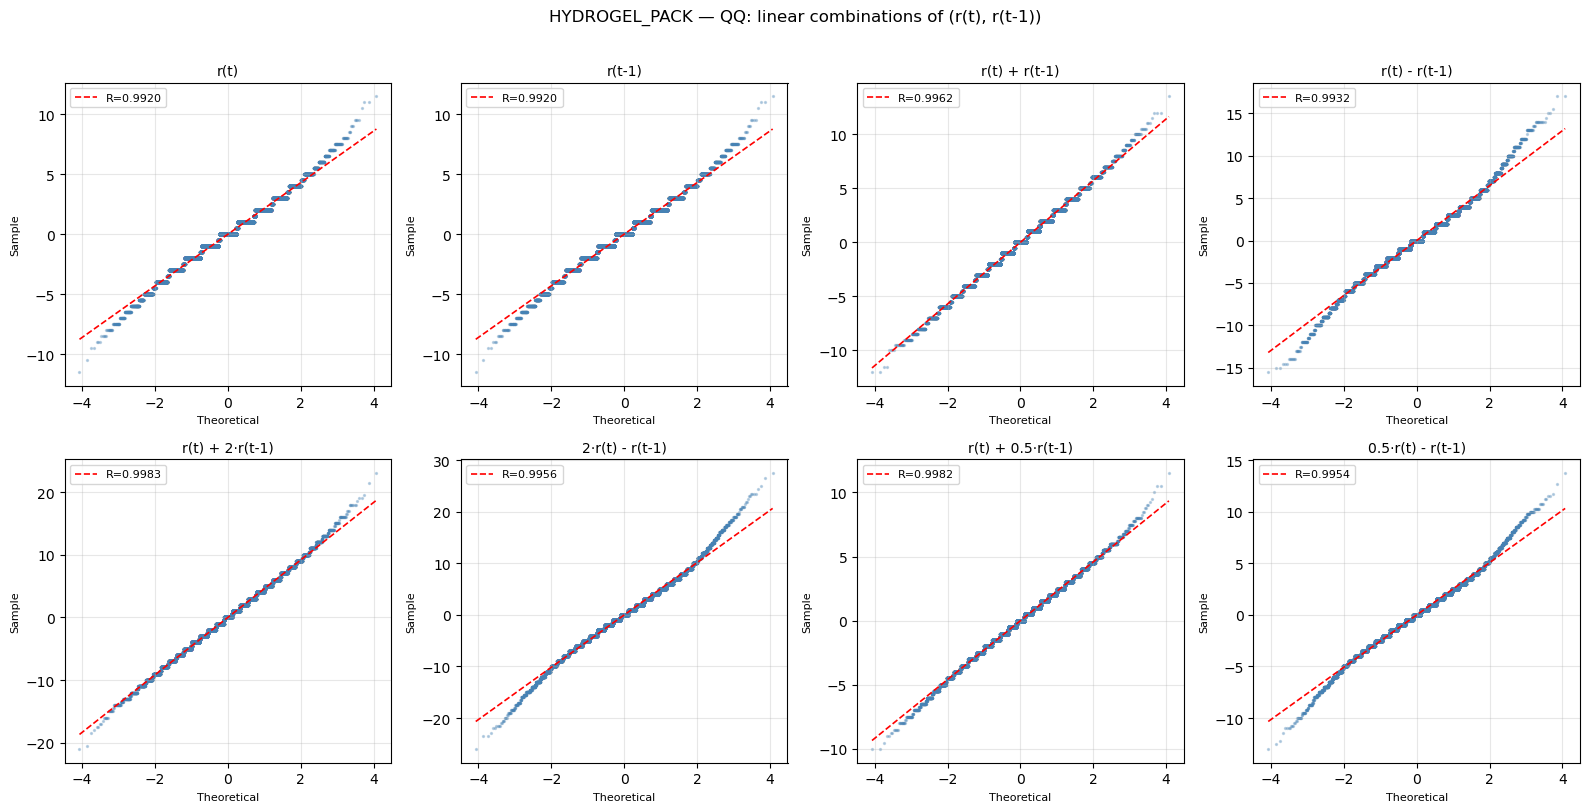


=== VELVETFRUIT_EXTRACT (n=29998) ===
Combination                    SW stat        SW p   KS stat        KS p  Normal?
--------------------------------------------------------------------------------
r(t)                            0.9761   3.401e-28    0.1252   0.000e+00  no
r(t-1)                          0.9760   3.185e-28    0.1252   0.000e+00  no
r(t) + r(t-1)                   0.9868   2.872e-21    0.0931  1.283e-226  no
r(t) - r(t-1)                   0.9864   1.482e-21    0.0874  1.206e-199  no
r(t) + 2·r(t-1)                 0.9942   2.452e-13    0.0588   9.639e-91  no
2·r(t) - r(t-1)                 0.9924   1.037e-15    0.0600   2.416e-94  no
r(t) + 0.5·r(t-1)               0.9943   3.245e-13    0.0626  1.198e-102  no
0.5·r(t) - r(t-1)               0.9923   7.802e-16    0.0601   1.093e-94  no


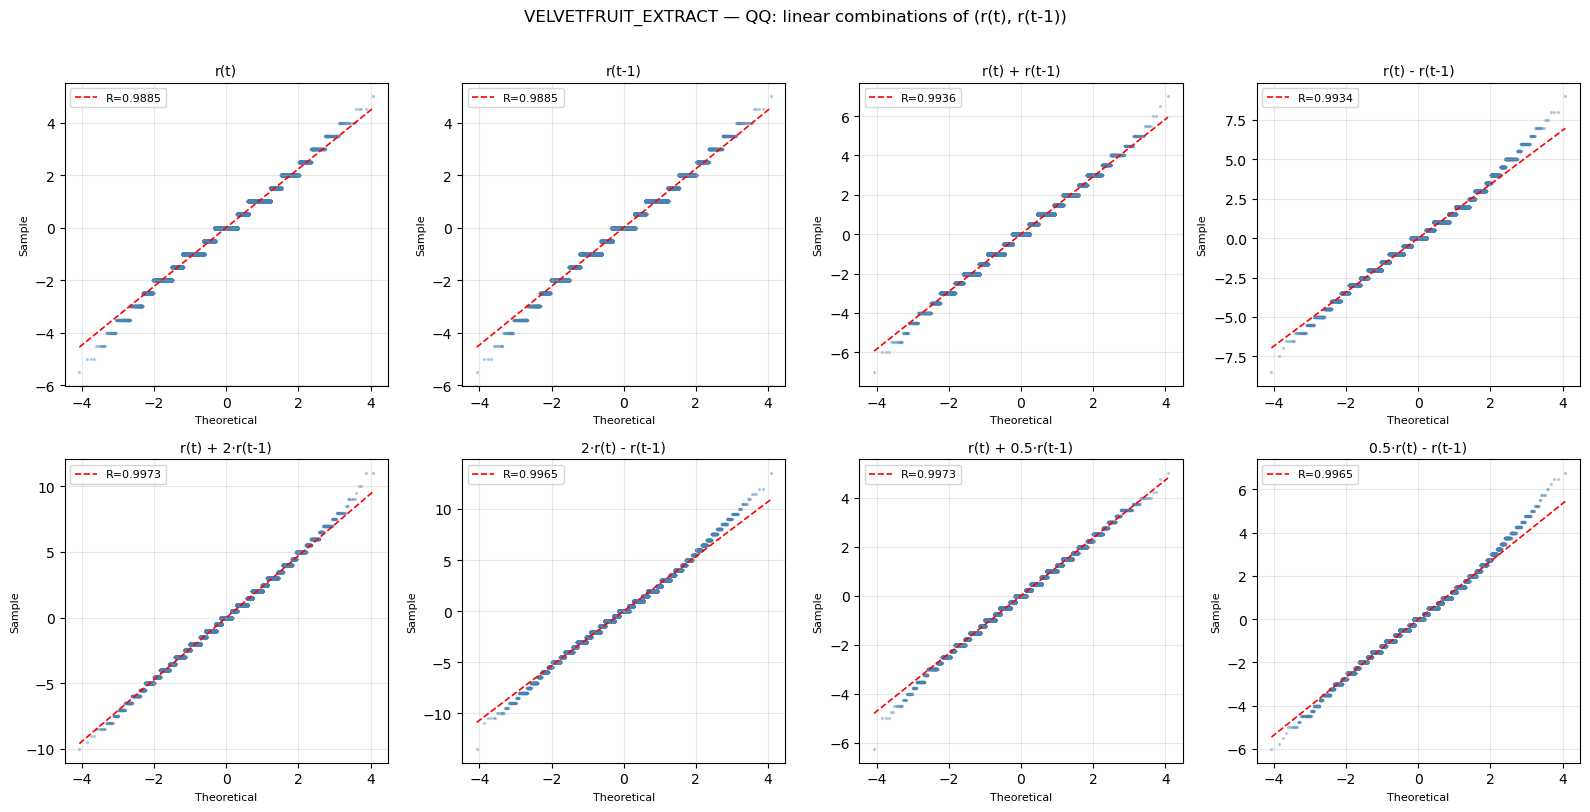

In [12]:
# Cramér-Wold: normality of linear combinations of (r(t), r(t-1))
combos = [
    (1,  0,   'r(t)'),
    (0,  1,   'r(t-1)'),
    (1,  1,   'r(t) + r(t-1)'),
    (1, -1,   'r(t) - r(t-1)'),
    (1,  2,   'r(t) + 2·r(t-1)'),
    (2, -1,   '2·r(t) - r(t-1)'),
    (1,  0.5, 'r(t) + 0.5·r(t-1)'),
    (0.5,-1,  '0.5·r(t) - r(t-1)'),
]

for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    r   = df['mid_price'].dropna().reset_index(drop=True).diff().dropna()
    biv = pd.DataFrame({'r(t)': r.values[1:], 'r(t-1)': r.values[:-1]})
    rt, rt1 = biv['r(t)'].values, biv['r(t-1)'].values
    n = len(rt)
    rng = np.random.default_rng(0)
    idx = rng.choice(n, size=min(n, 4999), replace=False)

    print(f'=== {label} (n={n}) ===')
    print(f'{"Combination":<28}  {"SW stat":>8}  {"SW p":>10}  {"KS stat":>8}  {"KS p":>10}  Normal?')
    print('-' * 80)

    lc_list = []
    for a, b, lbl in combos:
        lc = a * rt + b * rt1
        sw_s, sw_p = stats.shapiro(lc[idx])
        ks_s, ks_p = stats.kstest(lc, 'norm', args=(lc.mean(), lc.std()))
        flag = 'yes' if (sw_p > 0.05 and ks_p > 0.05) else 'no'
        print(f'{lbl:<28}  {sw_s:>8.4f}  {sw_p:>10.3e}  {ks_s:>8.4f}  {ks_p:>10.3e}  {flag}')
        lc_list.append((lbl, lc))

    ncols = 4
    nrows = (len(combos) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*4))
    axes = axes.flatten()
    for i, (lbl, lc) in enumerate(lc_list):
        ax = axes[i]
        (osm, osr), (slope, intercept, r_val) = stats.probplot(lc, dist='norm', plot=None)
        ax.scatter(osm, osr, s=2, alpha=0.3, color='steelblue')
        lx = np.array([osm.min(), osm.max()])
        ax.plot(lx, slope*lx+intercept, 'r--', lw=1.2, label=f'R={r_val:.4f}')
        ax.set_title(lbl, fontsize=10); ax.set_xlabel('Theoretical', fontsize=8)
        ax.set_ylabel('Sample', fontsize=8); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    for j in range(len(combos), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{label} — QQ: linear combinations of (r(t), r(t-1))', y=1.01)
    plt.tight_layout(); plt.show()
    print()

=== HYDROGEL_PACK ===
  Skewness  b1p=0.0085  Chi²=42.44  p=1.355e-08  ✗
  Kurtosis  b2p=9.5785  expected=8  z=34.18  p=0.000e+00  ✗


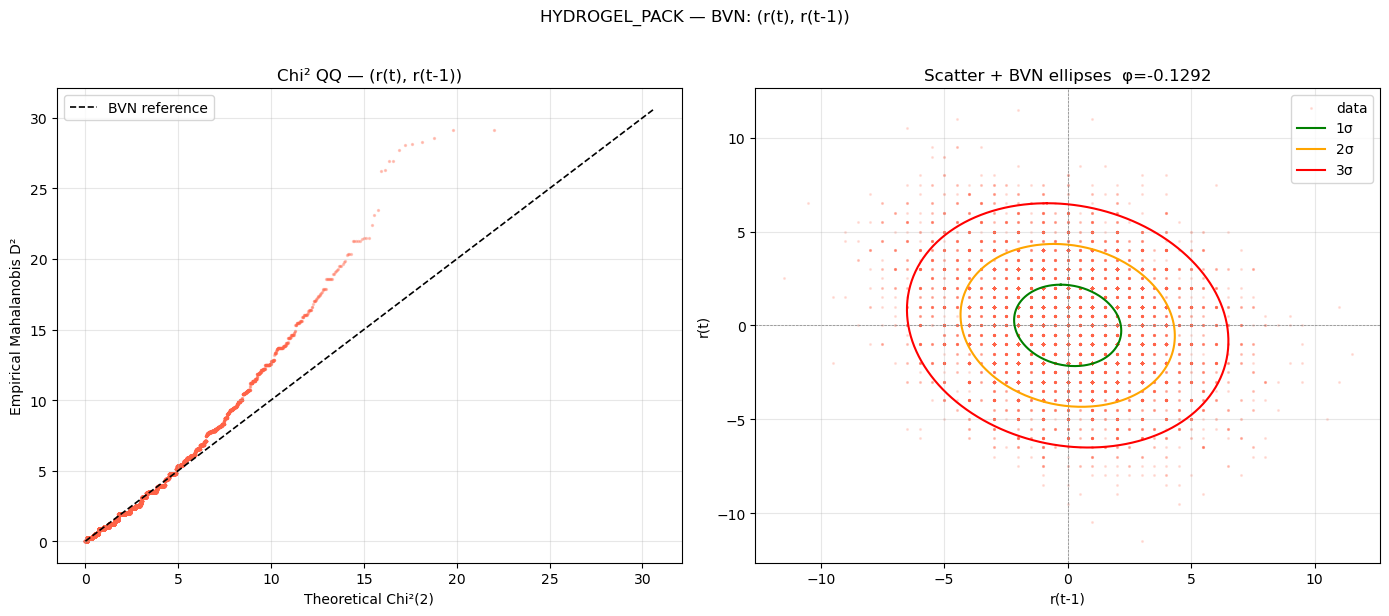


=== VELVETFRUIT_EXTRACT ===
  Skewness  b1p=0.0279  Chi²=139.46  p=0.000e+00  ✗
  Kurtosis  b2p=8.9479  expected=8  z=20.52  p=0.000e+00  ✗


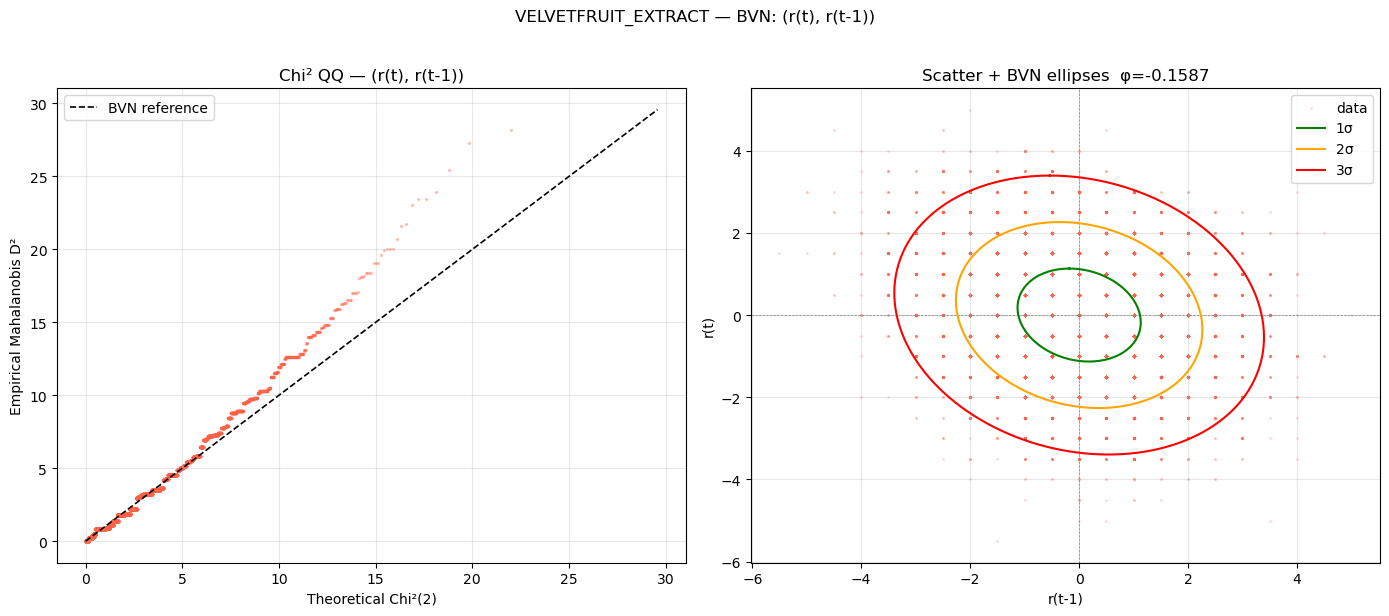

In [13]:
# Mardia's bivariate normality test on (r(t), r(t-1))
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    r   = df['mid_price'].dropna().reset_index(drop=True).diff().dropna()
    biv = pd.DataFrame({'r(t)': r.values[1:], 'r(t-1)': r.values[:-1]})
    X   = biv.values
    n, p = X.shape
    X_c  = X - X.mean(axis=0)
    S    = np.cov(X.T)
    S_inv = np.linalg.inv(S)
    D    = X_c @ S_inv @ X_c.T

    b1p       = (D**3).mean()
    chi2_stat = n * b1p / 6
    p_skew    = 1 - stats.chi2.cdf(chi2_stat, df=p*(p+1)*(p+2)//6)
    b2p       = np.mean(np.diag(D)**2)
    kurt_mean = p * (p + 2)
    z_kurt    = (b2p - kurt_mean) / np.sqrt(8 * p * (p+2) / n)
    p_kurt    = 2 * (1 - stats.norm.cdf(abs(z_kurt)))

    print(f"=== {label} ===")
    print(f"  Skewness  b1p={b1p:.4f}  Chi²={chi2_stat:.2f}  p={p_skew:.3e}  {'✓' if p_skew>0.05 else '✗'}")
    print(f"  Kurtosis  b2p={b2p:.4f}  expected={kurt_mean}  z={z_kurt:.2f}  p={p_kurt:.3e}  {'✓' if p_kurt>0.05 else '✗'}")

    D2_sq  = np.sort(np.diag(D))
    chi2_q = stats.chi2.ppf((np.arange(1, n+1) - 0.5) / n, df=2)
    L      = np.linalg.cholesky(S)
    mu2    = X.mean(axis=0)
    theta  = np.linspace(0, 2*np.pi, 300)
    circle = np.stack([np.cos(theta), np.sin(theta)])
    phi    = biv.corr().iloc[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(chi2_q, D2_sq, s=2, alpha=0.3, color='tomato')
    lim = max(chi2_q.max(), D2_sq.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='BVN reference')
    ax.set_xlabel('Theoretical Chi²(2)'); ax.set_ylabel('Empirical Mahalanobis D²')
    ax.set_title('Chi² QQ — (r(t), r(t-1))'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.scatter(biv['r(t-1)'], biv['r(t)'], s=1.5, alpha=0.15, color='tomato', label='data')
    ax.axhline(0, color='gray', lw=0.5, ls='--'); ax.axvline(0, color='gray', lw=0.5, ls='--')
    for nsig, col, lbl in [(1,'green','1σ'),(2,'orange','2σ'),(3,'red','3σ')]:
        e = mu2[:, None] + nsig * L @ circle
        ax.plot(e[1], e[0], color=col, lw=1.5, label=lbl)
    ax.set_xlabel('r(t-1)'); ax.set_ylabel('r(t)')
    ax.set_title(f'Scatter + BVN ellipses  φ={phi:.4f}'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'{label} — BVN: (r(t), r(t-1))', y=1.02)
    plt.tight_layout(); plt.show()
    print()

HYDROGEL_PACK
  k (reversion speed) = 0.002304
  mu (implied FV)     = 9990.9509
  R²                  = 0.001150
  residual std        = 2.168593


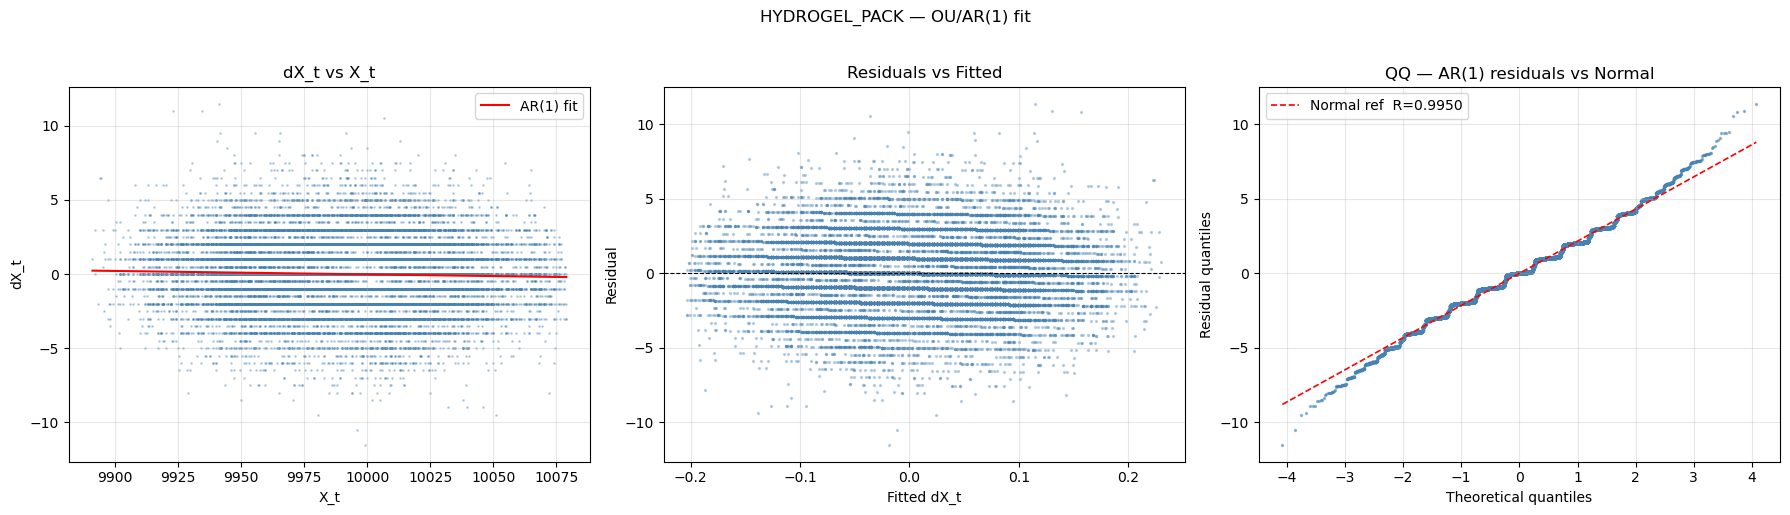


VELVETFRUIT_EXTRACT
  k (reversion speed) = 0.002479
  mu (implied FV)     = 5250.7084
  R²                  = 0.001173
  residual std        = 1.130530


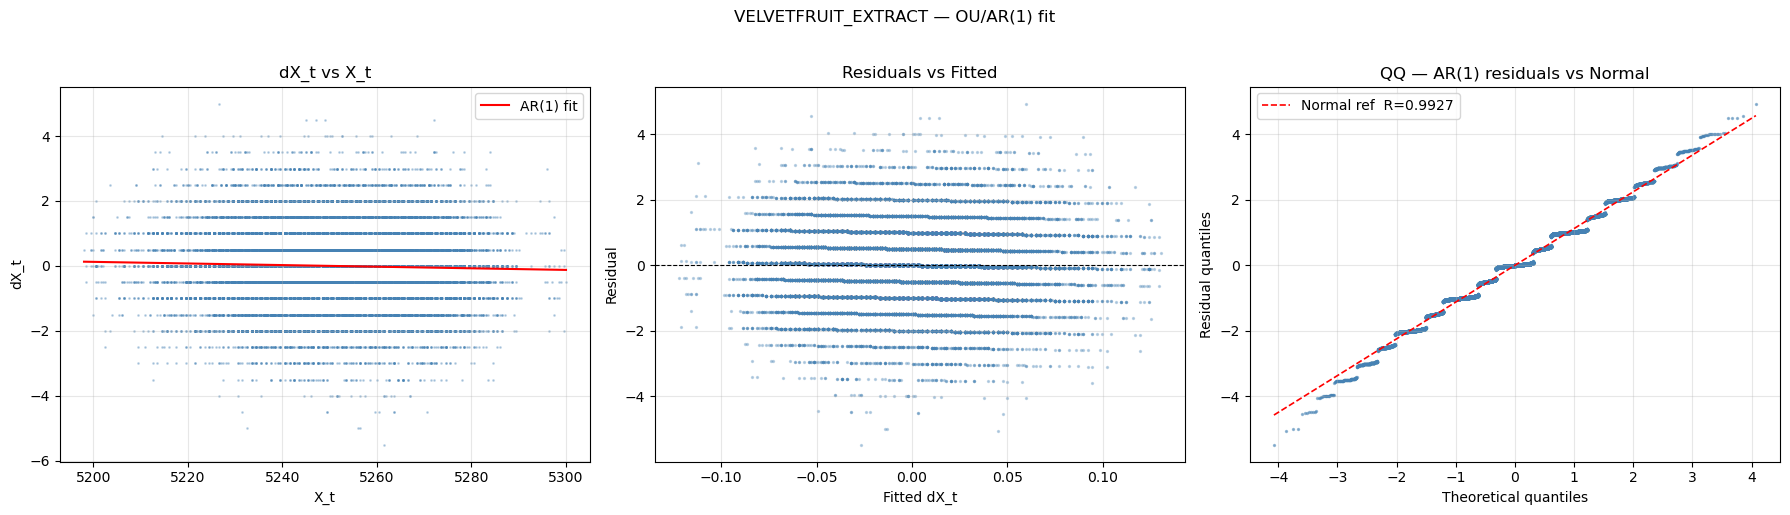

In [14]:
# OU / AR(1) fit: dX_t = k*(mu - X_t)*dt + eps  =>  dX_t = a + b*X_t + eps
for df, label in [(hp_prices, 'HYDROGEL_PACK'), (vfe_prices, 'VELVETFRUIT_EXTRACT')]:
    p  = df['mid_price'].dropna().values
    dX = p[1:] - p[:-1]
    X  = p[:-1].reshape(-1, 1)

    reg   = LinearRegression(fit_intercept=True).fit(X, dX)
    b, a  = reg.coef_[0], reg.intercept_
    k     = -b
    mu_ou = -a / b
    resid = dX - reg.predict(X)

    print(f'{label}')
    print(f'  k (reversion speed) = {k:.6f}')
    print(f'  mu (implied FV)     = {mu_ou:.4f}')
    print(f'  R²                  = {reg.score(X, dX):.6f}')
    print(f'  residual std        = {resid.std():.6f}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.scatter(X, dX, s=1, alpha=0.3, color='steelblue')
    xs = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    ax.plot(xs, reg.predict(xs), color='red', lw=1.5, label='AR(1) fit')
    ax.set_xlabel('X_t'); ax.set_ylabel('dX_t')
    ax.set_title('dX_t vs X_t'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.scatter(reg.predict(X), resid, s=2, alpha=0.3, color='steelblue')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Fitted dX_t'); ax.set_ylabel('Residual')
    ax.set_title('Residuals vs Fitted'); ax.grid(True, alpha=0.3)

    ax = axes[2]
    (osm, osr), (slope, intercept, r_val) = stats.probplot(resid, dist='norm', plot=None)
    ax.scatter(osm, osr, s=2, alpha=0.5, color='steelblue')
    lx = np.array([osm.min(), osm.max()])
    ax.plot(lx, slope*lx+intercept, 'r--', lw=1.2, label=f'Normal ref  R={r_val:.4f}')
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Residual quantiles')
    ax.set_title('QQ — AR(1) residuals vs Normal'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'{label} — OU/AR(1) fit', y=1.02)
    plt.tight_layout(); plt.show()
    print()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_joint_dynamics(df_prices, underlying_col, strike_list):
    """
    Plots the underlying price vs specific option strikes.
    df_prices: DataFrame with timestamp, underlying_mid, and various strike mid-prices.
    """
    fig, axes = plt.subplots(len(strike_list), 1, figsize=(12, 4 * len(strike_list)), sharex=True)
    
    if len(strike_list) == 1: axes = [axes]

    for i, strike in enumerate(strike_list):
        ax_underlying = axes[i]
        ax_option = ax_underlying.twinx()
        
        ln1 = ax_underlying.plot(df_prices['timestamp'], df_prices[underlying_col], 
                                 color='blue', label=f'Underlying', alpha=0.6)
        ln2 = ax_option.plot(df_prices['timestamp'], df_prices[f'call_{strike}'], 
                             color='orange', label=f'Call {strike}')
        
        ax_underlying.set_ylabel('Underlying Price')
        ax_option.set_ylabel(f'Call {strike} Price')
        
        # Combine legends
        lns = ln1 + ln2
        labs = [l.get_label() for l in lns]
        ax_underlying.legend(lns, labs, loc='upper left')
        
    plt.title("Joint Underlying and Option Price Dynamics")
    plt.tight_layout()
    plt.show()

def plot_empirical_delta(df, underlying_col, strike):
    """
    Visualizes the 'Real' Delta by plotting Option Price vs Underlying Price.
    """
    plt.figure(figsize=(8, 6))
    sns.regplot(x=underlying_col, y=f'call_{strike}', data=df, 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Empirical Delta: Call {strike} vs. Underlying')
    plt.xlabel('Underlying Price')
    plt.ylabel('Option Price')
    plt.show()

In [ ]:
plot_joint_dynamics(df_prices, 'underlying_mid', strike_list=[100, 110])